# Chunking Strategy Experiments

Comparing three chunking strategies on the Attention Is All You Need paper.

Goals:
- Understand how each strategy splits text differently
- Visualize chunk size distributions
- See where boundaries are placed

Strategies:
1. **Sliding Window** — fixed size with overlap
2. **Semantic** — splits on meaning shifts
3. **Hierarchical** — multi-level chunks

In [2]:
import sys
sys.path.append('..')

from src.data.loader import DocumentLoader

loader = DocumentLoader()
docs   = loader.load("../src/data/raw/attention_is_all_you_need.pdf")

print(f"Pages loaded: {len(docs)}")
print(f"Total characters: {sum(len(d.content) for d in docs)}")
print(f"\nFirst 500 chars of page 1:")
print(docs[0].content[:500])

2026-06-06 13:27:09 | INFO | src.data.loader | Loading PDF
2026-06-06 13:27:10 | INFO | src.data.loader | Loaded PDF
Pages loaded: 15
Total characters: 39567

First 500 chars of page 1:
Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.com
Noam Shazeer∗
Google Brain
noam@google.com
Niki Parmar∗
Google Research
nikip@google.com
Jakob Uszkoreit∗
Google Research
usz@google.com
Llion Jones∗
Google Research
llion@google.com
Aidan N. Gomez∗ †
University of Toronto
aidan@cs.toronto.edu
Łukasz 


## Strategy 1: Sliding Window

Fixed size chunks with overlap. Simple and predictable.
- chunk_size = 512 tokens
- chunk_overlap = 50 tokens
- step = 512 - 50 = 462 tokens

In [3]:
from src.data.chunker import get_chunker

sw_chunker = get_chunker("sliding_window")
sw_chunks  = sw_chunker.chunk(docs)

print(f"Total chunks: {len(sw_chunks)}")
print(f"Avg chunk size: {sum(len(c.content) for c in sw_chunks) / len(sw_chunks):.0f} chars")
print(f"Min chunk size: {min(len(c.content) for c in sw_chunks)} chars")
print(f"Max chunk size: {max(len(c.content) for c in sw_chunks)} chars")
print(f"\nExample chunk (index 5):")
print(sw_chunks[5].content)
print(f"\nMetadata: {sw_chunks[5].metadata}")

2026-06-06 13:27:37 | INFO | src.data.chunker | Sliding window chunking complete
Total chunks: 21
Avg chunk size: 1973 chars
Min chunk size: 229 chars
Max chunk size: 3544 chars

Example chunk (index 5):
output values. These are concatenated and once again projected, resulting in the final values, as depicted in Figure 2. Multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions. With a single attention head, averaging inhibits this. MultiHead(Q, K, V ) = Concat(head 1, ..., headh)W O where headi = Attention(QW Q i , KW K i , V W V i ) Where the projections are parameter matricesW Q i ∈ Rdmodel×dk, W K i ∈ Rdmodel×dk, W V i ∈ Rdmodel×dv and W O ∈ Rhdv×dmodel. In this work we employ h = 8 parallel attention layers, or heads. For each of these we use dk = dv = dmodel/h = 64. Due to the reduced dimension of each head, the total computational cost is similar to that of single-head attention with full dimensionality

## Strategy 2: Semantic Chunking

Splits text where meaning shifts significantly.
Uses cosine distance between consecutive sentence embeddings.
Threshold = 0.3 (splits when distance exceeds this value)

In [4]:
sem_chunker = get_chunker("semantic")
sem_chunks  = sem_chunker.chunk(docs)

print(f"Total chunks: {len(sem_chunks)}")
print(f"Avg chunk size: {sum(len(c.content) for c in sem_chunks) / len(sem_chunks):.0f} chars")
print(f"Min chunk size: {min(len(c.content) for c in sem_chunks)} chars")
print(f"Max chunk size: {max(len(c.content) for c in sem_chunks)} chars")
print(f"\nExample chunk (index 5):")
print(sem_chunks[5].content)

c:\Users\Snapp\anaconda3\envs\rag-eval\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-06-06 13:28:08 | INFO | src.data.chunker | Loading embedding model


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9280.83it/s]


2026-06-06 13:28:30 | INFO | src.data.chunker | Semantic chunking complete
Total chunks: 255
Avg chunk size: 154 chars
Min chunk size: 22 chars
Max chunk size: 796 chars

Example chunk (index 5):
Experiments on two machine translation tasks show these models to
be superior in quality while being more parallelizable and requiring significantly
less time to train.


## Strategy 3: Hierarchical Chunking

Creates chunks at two levels simultaneously:
- Parent chunks: ~1024 tokens (sections)
- Child chunks: ~256 tokens (paragraphs)

Each child knows its parent — enables small-to-big retrieval.

In [5]:
hier_chunker = get_chunker("hierarchical")
hier_chunks  = hier_chunker.chunk(docs)

parents  = [c for c in hier_chunks if c.metadata.get("level") == "parent"]
children = [c for c in hier_chunks if c.metadata.get("level") == "child"]

print(f"Total chunks: {len(hier_chunks)}")
print(f"Parent chunks: {len(parents)}")
print(f"Child chunks:  {len(children)}")
print(f"\nExample parent chunk:")
print(parents[0].content[:300])
print(f"\nExample child chunk from same parent:")
child = next(c for c in children if c.metadata.get("parent_id") == parents[0].metadata.get("parent_id"))
print(child.content[:300])

2026-06-06 13:29:01 | INFO | src.data.chunker | Hierarchical chunking complete
Total chunks: 52
Parent chunks: 15
Child chunks:  37

Example parent chunk:
Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works. Attention Is All You Need Ashish Vaswani∗ Google Brain avaswani@google.com Noam Shazeer∗ Google Brain noam@google.com Niki Par

Example child chunk from same parent:
Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works. Attention Is All You Need Ashish Vaswani∗ Google Brain avaswani@google.com Noam Shazeer∗ Google Brain noam@google.com Niki Par


## Visual Comparison

Chunk size distributions across all three strategies.

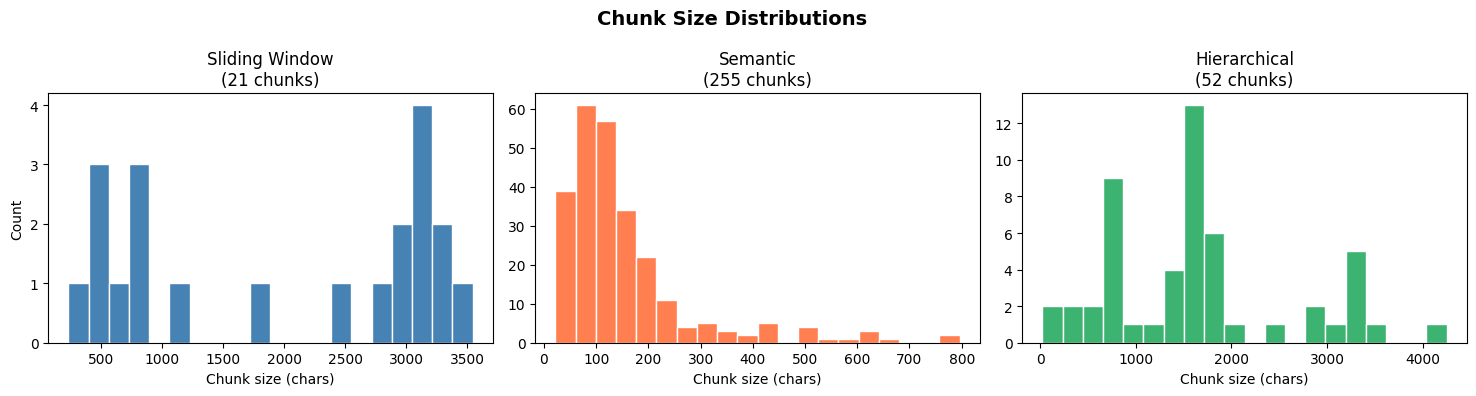


Summary:
Strategy                Count   Avg Size    Std Dev
--------------------------------------------------
Sliding Window             21       1973       1224
Semantic                  255        154        130
Hierarchical               52       1650        959


In [7]:
import matplotlib.pyplot as plt
import numpy as np

sw_sizes   = [len(c.content) for c in sw_chunks]
sem_sizes  = [len(c.content) for c in sem_chunks]
hier_sizes = [len(c.content) for c in hier_chunks]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Chunk Size Distributions", fontsize=14, fontweight='bold')

axes[0].hist(sw_sizes, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title(f"Sliding Window\n({len(sw_chunks)} chunks)")
axes[0].set_xlabel("Chunk size (chars)")
axes[0].set_ylabel("Count")

axes[1].hist(sem_sizes, bins=20, color='coral', edgecolor='white')
axes[1].set_title(f"Semantic\n({len(sem_chunks)} chunks)")
axes[1].set_xlabel("Chunk size (chars)")

axes[2].hist(hier_sizes, bins=20, color='mediumseagreen', edgecolor='white')
axes[2].set_title(f"Hierarchical\n({len(hier_chunks)} chunks)")
axes[2].set_xlabel("Chunk size (chars)")

plt.tight_layout()
plt.savefig("../src/data/eval_datasets/chunking_distributions.png", dpi=150)
plt.show()

print("\nSummary:")
print(f"{'Strategy':<20} {'Count':>8} {'Avg Size':>10} {'Std Dev':>10}")
print("-" * 50)
for name, sizes in [("Sliding Window", sw_sizes), ("Semantic", sem_sizes), ("Hierarchical", hier_sizes)]:
    print(f"{name:<20} {len(sizes):>8} {np.mean(sizes):>10.0f} {np.std(sizes):>10.0f}")

## Key Observations

After running the cells above, note:

1. **Sliding window** produces uniform chunk sizes — predictable but ignores content boundaries
2. **Semantic** produces variable sizes — respects meaning but can create very large chunks
3. **Hierarchical** produces a bimodal distribution — small children and large parents

The standard deviation tells the story:
- Low std = uniform chunks (sliding window)
- High std = variable chunks (semantic, hierarchical)

For the Attention paper specifically, semantic chunking should respect
section boundaries (Introduction, Model Architecture, Attention, etc.)
while sliding window cuts through them blindly.